In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device to GPU if available (Kaggle provides T4 GPUs)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load Fashion-MNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# Create DataLoaders
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 21.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 341kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.29MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.8MB/s]


In [2]:
class ConvolutionalAutoencoder(nn.Module):
    def __init__(self):
        super(ConvolutionalAutoencoder, self).__init__()
        
        # ENCODER
        # Input: (1, 28, 28) -> Output: (16, 14, 14)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            # Input: (16, 14, 14) -> Output: (32, 7, 7)
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )
        
        # DECODER
        self.decoder = nn.Sequential(
            # Input: (32, 7, 7) -> Output: (16, 14, 14)
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # Input: (16, 14, 14) -> Output: (1, 28, 28)
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() # Sigmoid scales output pixels between 0 and 1
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Initialize model, loss function, and optimizer
acn_model = ConvolutionalAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(acn_model.parameters(), lr=0.001)

print(acn_model)

ConvolutionalAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)


In [3]:
epochs = 10

print("Training Standard ACN...")
for epoch in range(epochs):
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        
        # Forward pass
        outputs = acn_model(images)
        loss = criterion(outputs, images) # Compare output to ORIGINAL image
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Training Standard ACN...
Epoch [1/10], Loss: 0.0133
Epoch [2/10], Loss: 0.0022
Epoch [3/10], Loss: 0.0014
Epoch [4/10], Loss: 0.0011
Epoch [5/10], Loss: 0.0010
Epoch [6/10], Loss: 0.0008
Epoch [7/10], Loss: 0.0007
Epoch [8/10], Loss: 0.0007
Epoch [9/10], Loss: 0.0006
Epoch [10/10], Loss: 0.0006


In [4]:
# Create a fresh instance of the model for denoising
denoising_model = ConvolutionalAutoencoder().to(device)
denoising_optimizer = optim.Adam(denoising_model.parameters(), lr=0.001)

noise_factor = 0.2

print("Training Denoising Autoencoder...")
for epoch in range(epochs):
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        
        # ADD NOISE TO THE INPUT
        noisy_images = images + noise_factor * torch.randn_like(images).to(device)
        noisy_images = torch.clamp(noisy_images, 0., 1.) # Ensure pixels are still between 0 and 1
        
        # Forward pass
        outputs = denoising_model(noisy_images)
        
        # CRITICAL: Compare output to the CLEAN images, not the noisy ones
        loss = criterion(outputs, images) 
        
        # Backward pass
        denoising_optimizer.zero_grad()
        loss.backward()
        denoising_optimizer.step()
        
        running_loss += loss.item()
        
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Training Denoising Autoencoder...
Epoch [1/10], Loss: 0.0188
Epoch [2/10], Loss: 0.0083
Epoch [3/10], Loss: 0.0077
Epoch [4/10], Loss: 0.0074
Epoch [5/10], Loss: 0.0072
Epoch [6/10], Loss: 0.0071
Epoch [7/10], Loss: 0.0070
Epoch [8/10], Loss: 0.0070
Epoch [9/10], Loss: 0.0069
Epoch [10/10], Loss: 0.0069


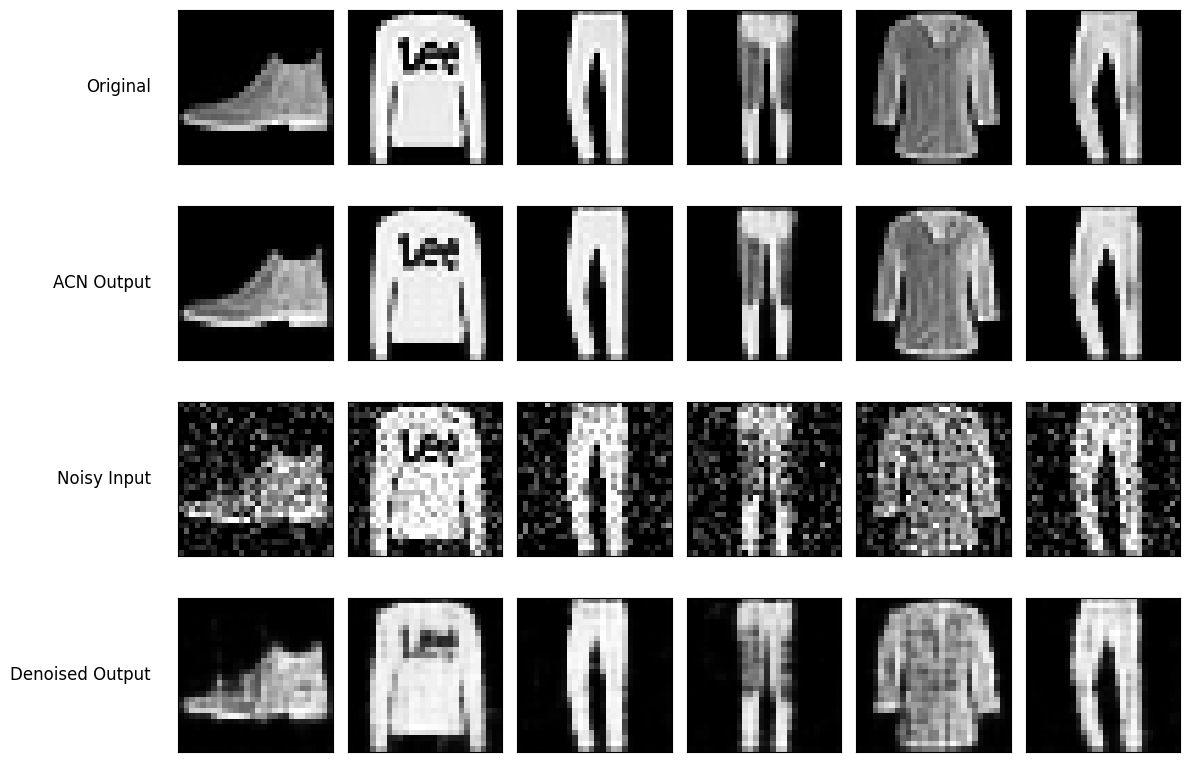

In [5]:
# Grab a single batch of test images
dataiter = iter(test_loader)
images, _ = next(dataiter)
images = images.to(device)

# Generate standard ACN outputs
acn_outputs = acn_model(images)

# Generate Noisy images and Denoising model outputs
noisy_images = images + noise_factor * torch.randn_like(images).to(device)
noisy_images = torch.clamp(noisy_images, 0., 1.)
denoised_outputs = denoising_model(noisy_images)

# Move tensors to CPU for plotting
images = images.cpu().numpy()
acn_outputs = acn_outputs.detach().cpu().numpy()
noisy_images = noisy_images.cpu().numpy()
denoised_outputs = denoised_outputs.detach().cpu().numpy()

# Plot the results
fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(12, 8))
row_labels = ['Original', 'ACN Output', 'Noisy Input', 'Denoised Output']

for idx, ax_row in enumerate(axes):
    # Add row labels
    ax_row[0].set_ylabel(row_labels[idx], size='large', labelpad=20, rotation=0, va='center', ha='right')
    
    for i, ax in enumerate(ax_row):
        if idx == 0:
            ax.imshow(np.squeeze(images[i]), cmap='gray')
        elif idx == 1:
            ax.imshow(np.squeeze(acn_outputs[i]), cmap='gray')
        elif idx == 2:
            ax.imshow(np.squeeze(noisy_images[i]), cmap='gray')
        elif idx == 3:
            ax.imshow(np.squeeze(denoised_outputs[i]), cmap='gray')
            
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

In [6]:
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        
        # Encoder
        self.fc1 = nn.Linear(784, 400)
        
        # Latent space (Bottleneck)
        self.fc_mu = nn.Linear(400, 20)      # Mean of the distribution
        self.fc_logvar = nn.Linear(400, 20)  # Log-variance of the distribution
        
        # Decoder
        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        # The Reparameterization Trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784)) # Flatten image
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

vae_model = VAE().to(device)
vae_optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)

In [7]:
# VAE loss requires both Reconstruction Loss (BCE) and KL Divergence
def vae_loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    # KL Divergence pushes the distribution to be close to a standard normal distribution
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

print("Training Variational Autoencoder (VAE)...")
vae_model.train()
for epoch in range(epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        vae_optimizer.zero_grad()
        
        recon_batch, mu, logvar = vae_model(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        
        loss.backward()
        train_loss += loss.item()
        vae_optimizer.step()
        
    print(f"Epoch [{epoch+1}/{epochs}], VAE Loss: {train_loss / len(train_loader.dataset):.4f}")

Training Variational Autoencoder (VAE)...
Epoch [1/10], VAE Loss: 274.2283
Epoch [2/10], VAE Loss: 251.4550
Epoch [3/10], VAE Loss: 247.3487
Epoch [4/10], VAE Loss: 245.4702
Epoch [5/10], VAE Loss: 244.4183
Epoch [6/10], VAE Loss: 243.5482
Epoch [7/10], VAE Loss: 242.9529
Epoch [8/10], VAE Loss: 242.5137
Epoch [9/10], VAE Loss: 242.0572
Epoch [10/10], VAE Loss: 241.7118


Extracting features and computing t-SNE... (This may take a minute)


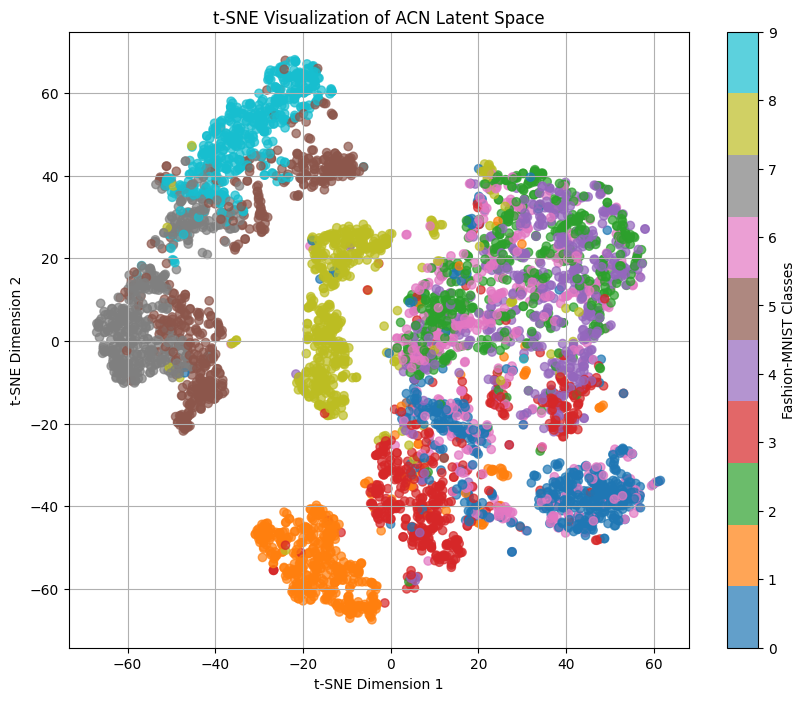

In [8]:
from sklearn.manifold import TSNE
import matplotlib.cm as cm

# Function to get latent representations from the standard ACN
def get_latent_features(model, dataloader):
    model.eval()
    latent_vecs = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            # Pass through just the encoder
            encoded = model.encoder(images)
            # Flatten the encoded output for t-SNE
            encoded = encoded.view(encoded.size(0), -1) 
            
            latent_vecs.append(encoded.cpu().numpy())
            labels_list.append(labels.numpy())
            
    return np.concatenate(latent_vecs), np.concatenate(labels_list)

print("Extracting features and computing t-SNE... (This may take a minute)")
latent_features, labels = get_latent_features(acn_model, test_loader)

# Limit to 5000 samples for faster t-SNE computation
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_features[:5000])
labels_subset = labels[:5000]

# Plot the clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels_subset, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='Fashion-MNIST Classes')
plt.title('t-SNE Visualization of ACN Latent Space')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()